# Implementing tail distributions

This notebook outlines the API for `TailDist` objects in the `empiricaldist` library.

A `TailDist` represents the tail distribution **P(X ≥ x)**. It is similar to a survival function, but a `Surv` object represents **P(X > x)**. The difference matters when a distribution has point masses, as empirical distributions often do.

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/empiricaldist/blob/master/empiricaldist/tail_demo.ipynb).

In [1]:
try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import inspect

def psource(obj):
    """Prints the source code for a given object.

    obj: function or method object
    """
    print(inspect.getsource(obj))

## Tail vs survival

For a discrete distribution with sorted support qᵢ:

- **Tail:** T(qᵢ) = P(X ≥ qᵢ)
- **Survival:** S(qᵢ) = P(X > qᵢ)

At each support point, T(x) = S(x) + P(X = x). Equivalently, S(qᵢ) = T(qᵢ₊₁), with S at the last support point equal to 0.

We'll use this sequence as a running example:

In [4]:
t = [1, 2, 2, 3, 5]

In [5]:
from empiricaldist import Pmf, Surv, TailDist

pmf = Pmf.from_seq(t)
surv = Surv.from_seq(t)
tail = TailDist.from_seq(t)

The PMF gives the probability of each quantity:

In [6]:
pmf

,probs
1,0.2
2,0.4
3,0.2
5,0.2


The survival function gives P(X > x):

In [7]:
surv

,probs
1,0.8
2,0.4
3,0.2
5,0.0


The tail distribution gives P(X ≥ x):

In [8]:
tail

,probs
1,1.0
2,0.8
3,0.4
5,0.2


Notice that the tail at each support point includes the point mass at that quantity. For example, P(X ≥ 5) = 0.2 because all of the probability at 5 is included.

## Constructor

The `TailDist` class inherits its constructor from `pd.Series`.

You can build a tail distribution from a PMF by adding the survival function and the PMF, then wrapping the result in a `TailDist`:

In [9]:
ps = pmf.make_surv() + pmf
tail2 = TailDist(ps)
tail2.normalize()
tail2.iloc[0] = 1.0
tail2

,probs
1,1.0
2,0.8
3,0.4
5,0.2


Or use `from_seq`, which does this for you:

In [10]:
psource(TailDist.from_seq)

    @staticmethod
    def from_seq(seq, normalize=True, sort=True, **kwargs):
        """Make a TailDist from a sequence of values.

        Args:
            seq: iterable
            normalize: whether to normalize the TailDist, default True
            sort: whether to sort quantities, default True
            kwargs: passed to the TailDist constructor

        Returns: TailDist
        """
        pmf = Pmf.from_seq(seq, normalize=False, sort=sort, **kwargs)
        return pmf.make_tail(normalize=normalize)



In [11]:
tail = TailDist.from_seq(t)
tail

,probs
1,1.0
2,0.8
3,0.4
5,0.2


Other distribution classes provide `make_tail`, which returns the same result:

In [12]:
psource(Pmf.make_tail)

    def make_tail(self, **kwargs):
        """Make a TailDist from the Pmf.

        Args:
            kwargs: passed to the TailDist constructor

        Returns: TailDist
        """
        normalize = kwargs.pop("normalize", False)
        ps = self.make_surv() + self
        tail = TailDist(ps, **kwargs)
        tail.attrs["total"] = ps.iloc[0]
        if normalize:
            tail.normalize()
            tail.iloc[0] = 1.0
        return tail



In [13]:
pmf.make_tail()

,probs
1,1.0
2,0.8
3,0.4
5,0.2


In [14]:
from empiricaldist import Cdf

Cdf.from_seq(t).make_tail()

,probs
1,1.0
2,0.8
3,0.4
5,0.2


In [15]:
surv.make_tail()

,probs
1,1.0
2,0.8
3,0.4
5,0.2


## Properties

In a `TailDist` the index contains the quantities (`qs`) and the values contain the tail probabilities (`ps`).

In [16]:
tail.qs

array([1, 2, 3, 5])

In [17]:
tail.ps

array([1. , 0.8, 0.4, 0.2])

## Displaying tail distributions

`TailDist` provides `plot` and `step`, which draw the tail as a line or step function.

In [18]:
def decorate_tail(title):
    """Labels the axes.

    title: string
    """
    plt.xlabel('Quantity')
    plt.ylabel('P(X ≥ x)')
    plt.title(title)

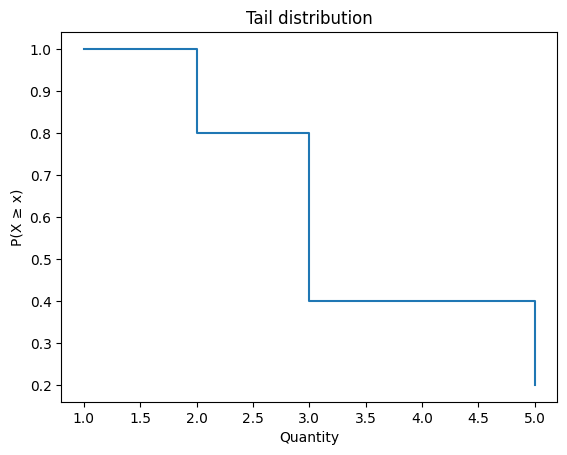

In [19]:
tail.step()
decorate_tail('Tail distribution')

Compare the tail with the survival function on the same axes:

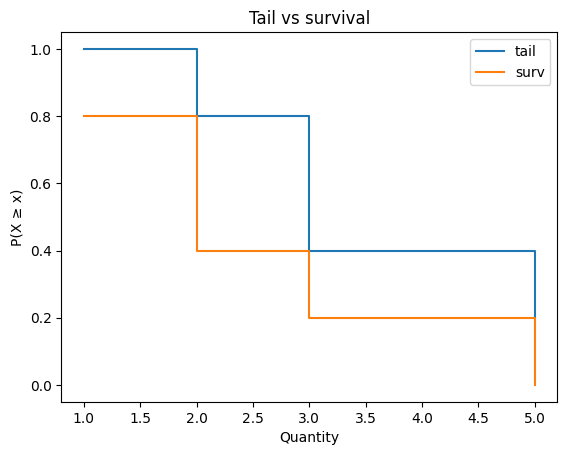

In [20]:
tail.step(label='tail')
surv.step(label='surv')
decorate_tail('Tail vs survival')
plt.legend();

## Evaluating tail distributions

Evaluating a `TailDist` forward maps from a quantity to P(X ≥ x).

In [21]:
tail(1)

array(1.)

In [22]:
tail(2)

array(0.8)

In [23]:
tail(3.5)

array(0.4)

`__call__` is a synonym for `forward`, so you can call a `TailDist` like a function.

In [24]:
tail(5)

array(0.2)

`inverse` maps from a tail probability to a quantity:

In [25]:
tail.inverse(1)

array(1.)

In [26]:
tail.inverse(0.8)

array(2.)

In [27]:
tail.inverse(0.2)

array(5.)

`quantile` is a synonym for `inverse`.

In [28]:
tail.quantile(0.4)

array(3.)

## Converting to other representations

`TailDist` provides the same conversion methods as the other distribution classes.

### Surv

`make_surv` converts a tail distribution to a survival function using

    surv[i] = tail[i + 1]

with `surv[-1] = 0`.

In [29]:
psource(TailDist.make_surv)

    def make_surv(self, **kwargs):
        """Make a Surv from the TailDist.

        If tail[i] = P(X >= q_i), then

            surv[i] = P(X > q_i) = P(X >= q_{i+1})

        with surv[-1] = 0.
        """
        normalize = kwargs.pop("normalize", False)

        tail = self.sort_index()
        ps = np.append(tail.ps[1:], 0)

        surv = Surv(ps, index=tail.index.copy(), **kwargs)
        surv.attrs["total"] = self.attrs.get("total", tail.ps[0])

        if normalize:
            surv.normalize()

        return surv



In [30]:
surv2 = tail.make_surv()
surv2

,probs
1,0.8
2,0.4
3,0.2
5,0.0


The result matches `Surv.from_seq`:

In [31]:
np.allclose(surv2.ps, surv.ps)

True

### Pmf

`make_pmf` recovers the PMF by differencing adjacent tail probabilities.

In [32]:
psource(TailDist.make_pmf)

    def make_pmf(self, **kwargs):
        """Make a Pmf from the TailDist."""
        normalize = kwargs.pop("normalize", False)
        tail = self.sort_index()
        ps = -np.diff(np.append(tail.ps, 0))
        pmf = Pmf(ps, index=tail.index.copy(), **kwargs)
        if normalize:
            pmf.normalize()
        return pmf



In [33]:
pmf2 = tail.make_pmf()
pmf2

,probs
1,0.2
2,0.4
3,0.2
5,0.2


In [34]:
np.allclose(pmf2.ps, pmf.ps)

True

### Cdf

`make_cdf` goes through the PMF.

In [35]:
from empiricaldist import Cdf

cdf = Cdf.from_seq(t)
cdf2 = tail.make_cdf()
np.allclose(cdf2.ps, cdf.ps)

True

Round-trip conversions preserve the distribution:

In [36]:
tail3 = pmf.make_tail()
np.allclose(tail3.ps, tail.ps)

True

In [37]:
pmf3 = tail.make_surv().make_pmf()
np.allclose(pmf3.ps, pmf.ps)

True

## Normalize

`normalize` divides through by the total tail mass at the leftmost support point.

In [38]:
psource(TailDist.normalize)

    def normalize(self):
        """Normalize the tail distribution (modifies self).

        Returns: normalizing constant
        """
        old_total = self.attrs.get("total", self.ps[0])
        self /= old_total
        self.attrs["total"] = 1.0
        return old_total



In [39]:
tail = TailDist.from_seq(t, normalize=False)
tail

,probs
1,5
2,4
3,2
5,1


In [40]:
total = tail.normalize()
total

5

In [41]:
tail

,probs
1,1.0
2,0.8
3,0.4
5,0.2


Copyright 2019 Allen Downey

BSD 3-clause license: https://opensource.org/licenses/BSD-3-Clause